## Requirements to run this notebook standalone

Run **Task02_03_Data_Understanding_Preprocessing.ipynb** first (or place its output file `model_df.csv` in the same folder as this notebook).

This notebook covers **Task 04 (Exploratory Data Analysis)**.

# Task 04 - Exploratory Data Analysis (EDA)

This part of the notebook performs exploratory data analysis on the cleaned dataset from Task 03:

1. Descriptive statistics
2. Target class distribution
3. Distribution analysis (histograms)
4. Boxplots — numeric features vs. target
5. Categorical feature patterns vs. target
6. Correlation analysis (heatmap)
7. Scatterplot analysis
8. Pattern discovery
9. Summary of insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model_df = pd.read_csv('../data/processed/model_df.csv')
print('Loaded model_df.csv, shape:', model_df.shape)

Loaded model_df.csv, shape: (1000, 35)


In [3]:
eda_df = model_df.copy()
target = 'readmitted_30_days'

print('EDA dataframe shape:', eda_df.shape)
eda_df.head()

EDA dataframe shape: (1000, 35)


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,...,appointment_month,appointment_dayofweek,zero_room_charge_flag,total_prior_visits,missed_appointment_rate,bmi_category,bp_category,high_utilisation,avg_charge_per_treatment,is_weekend_appointment
0,53,Male,A-,General Medicine,Migraine,10,1,0,Completed,0,...,4,3,0,2,0.000000,2,1,0,3399.0,0
1,26,Male,B-,General Medicine,Diabetes,2,3,1,Completed,0,...,5,3,0,3,0.333333,3,1,0,2826.0,0
2,22,Male,B+,Orthopedics,Back Pain,22,7,1,No-Show,0,...,7,2,0,8,0.142857,2,2,0,6262.0,0
3,44,Female,AB-,Cardiology,Asthma,16,1,0,Completed,0,...,10,3,0,1,0.000000,1,1,0,8631.0,0
4,51,Female,O+,Neurology,Hypertension,12,4,0,Scheduled,0,...,12,3,0,5,0.000000,2,1,0,20414.0,0


## 4.1. Descriptive Statistics

In [4]:
eda_numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
eda_categorical_cols = eda_df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns ({len(eda_numeric_cols)}):')
print(eda_numeric_cols)
print(f'\nCategorical columns ({len(eda_categorical_cols)}):')
print(eda_categorical_cols)

Numeric columns (27):
['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'admitted', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'total_bill_lkr', 'readmitted_30_days', 'admission_status_conflict', 'appointment_month', 'appointment_dayofweek', 'zero_room_charge_flag', 'total_prior_visits', 'missed_appointment_rate', 'bmi_category', 'bp_category', 'high_utilisation', 'avg_charge_per_treatment', 'is_weekend_appointment']

Categorical columns (8):
['gender', 'blood_group', 'department', 'diagnosis', 'appointment_status', 'room_type', 'payment_status', 'payment_method']


C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\3648936822.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  eda_categorical_cols = eda_df.select_dtypes(include=['object']).columns.tolist()


In [5]:
eda_df[eda_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,44.744000,17.851474,1.000000,33.0000,44.000,57.000000,90.0
waiting_days,1000.0,21.851000,13.040892,0.000000,11.0000,22.000,34.000000,44.0
previous_appointments,1000.0,2.884000,1.693343,0.000000,2.0000,3.000,4.000000,10.0
missed_previous_appointments,1000.0,0.537000,0.741067,0.000000,0.0000,0.000,1.000000,4.0
admitted,1000.0,0.330000,0.470448,0.000000,0.0000,0.000,1.000000,1.0
length_of_stay_days,1000.0,1.103000,1.885191,0.000000,0.0000,0.000,2.000000,9.0
previous_admissions,1000.0,0.855000,0.958590,0.000000,0.0000,1.000,1.000000,5.0
systolic_bp,1000.0,128.423000,15.486895,85.000000,117.0000,128.000,139.000000,178.0
diastolic_bp,1000.0,78.828000,10.043669,50.000000,72.0000,79.000,86.000000,111.0
blood_sugar_mg_dl,1000.0,114.832000,26.017007,65.000000,97.0000,114.000,132.000000,201.0


In [6]:
eda_df[eda_categorical_cols].describe().T

,count,unique,top,freq
gender,1000,2,Male,501
blood_group,1000,8,AB-,136
department,1000,7,General Medicine,159
diagnosis,1000,10,Pneumonia,115
appointment_status,1000,4,No-Show,495
room_type,1000,5,Not Admitted,670
payment_status,1000,3,Paid,668
payment_method,1000,4,Insurance,259


## 4.2. Distribution Analysis - Histograms

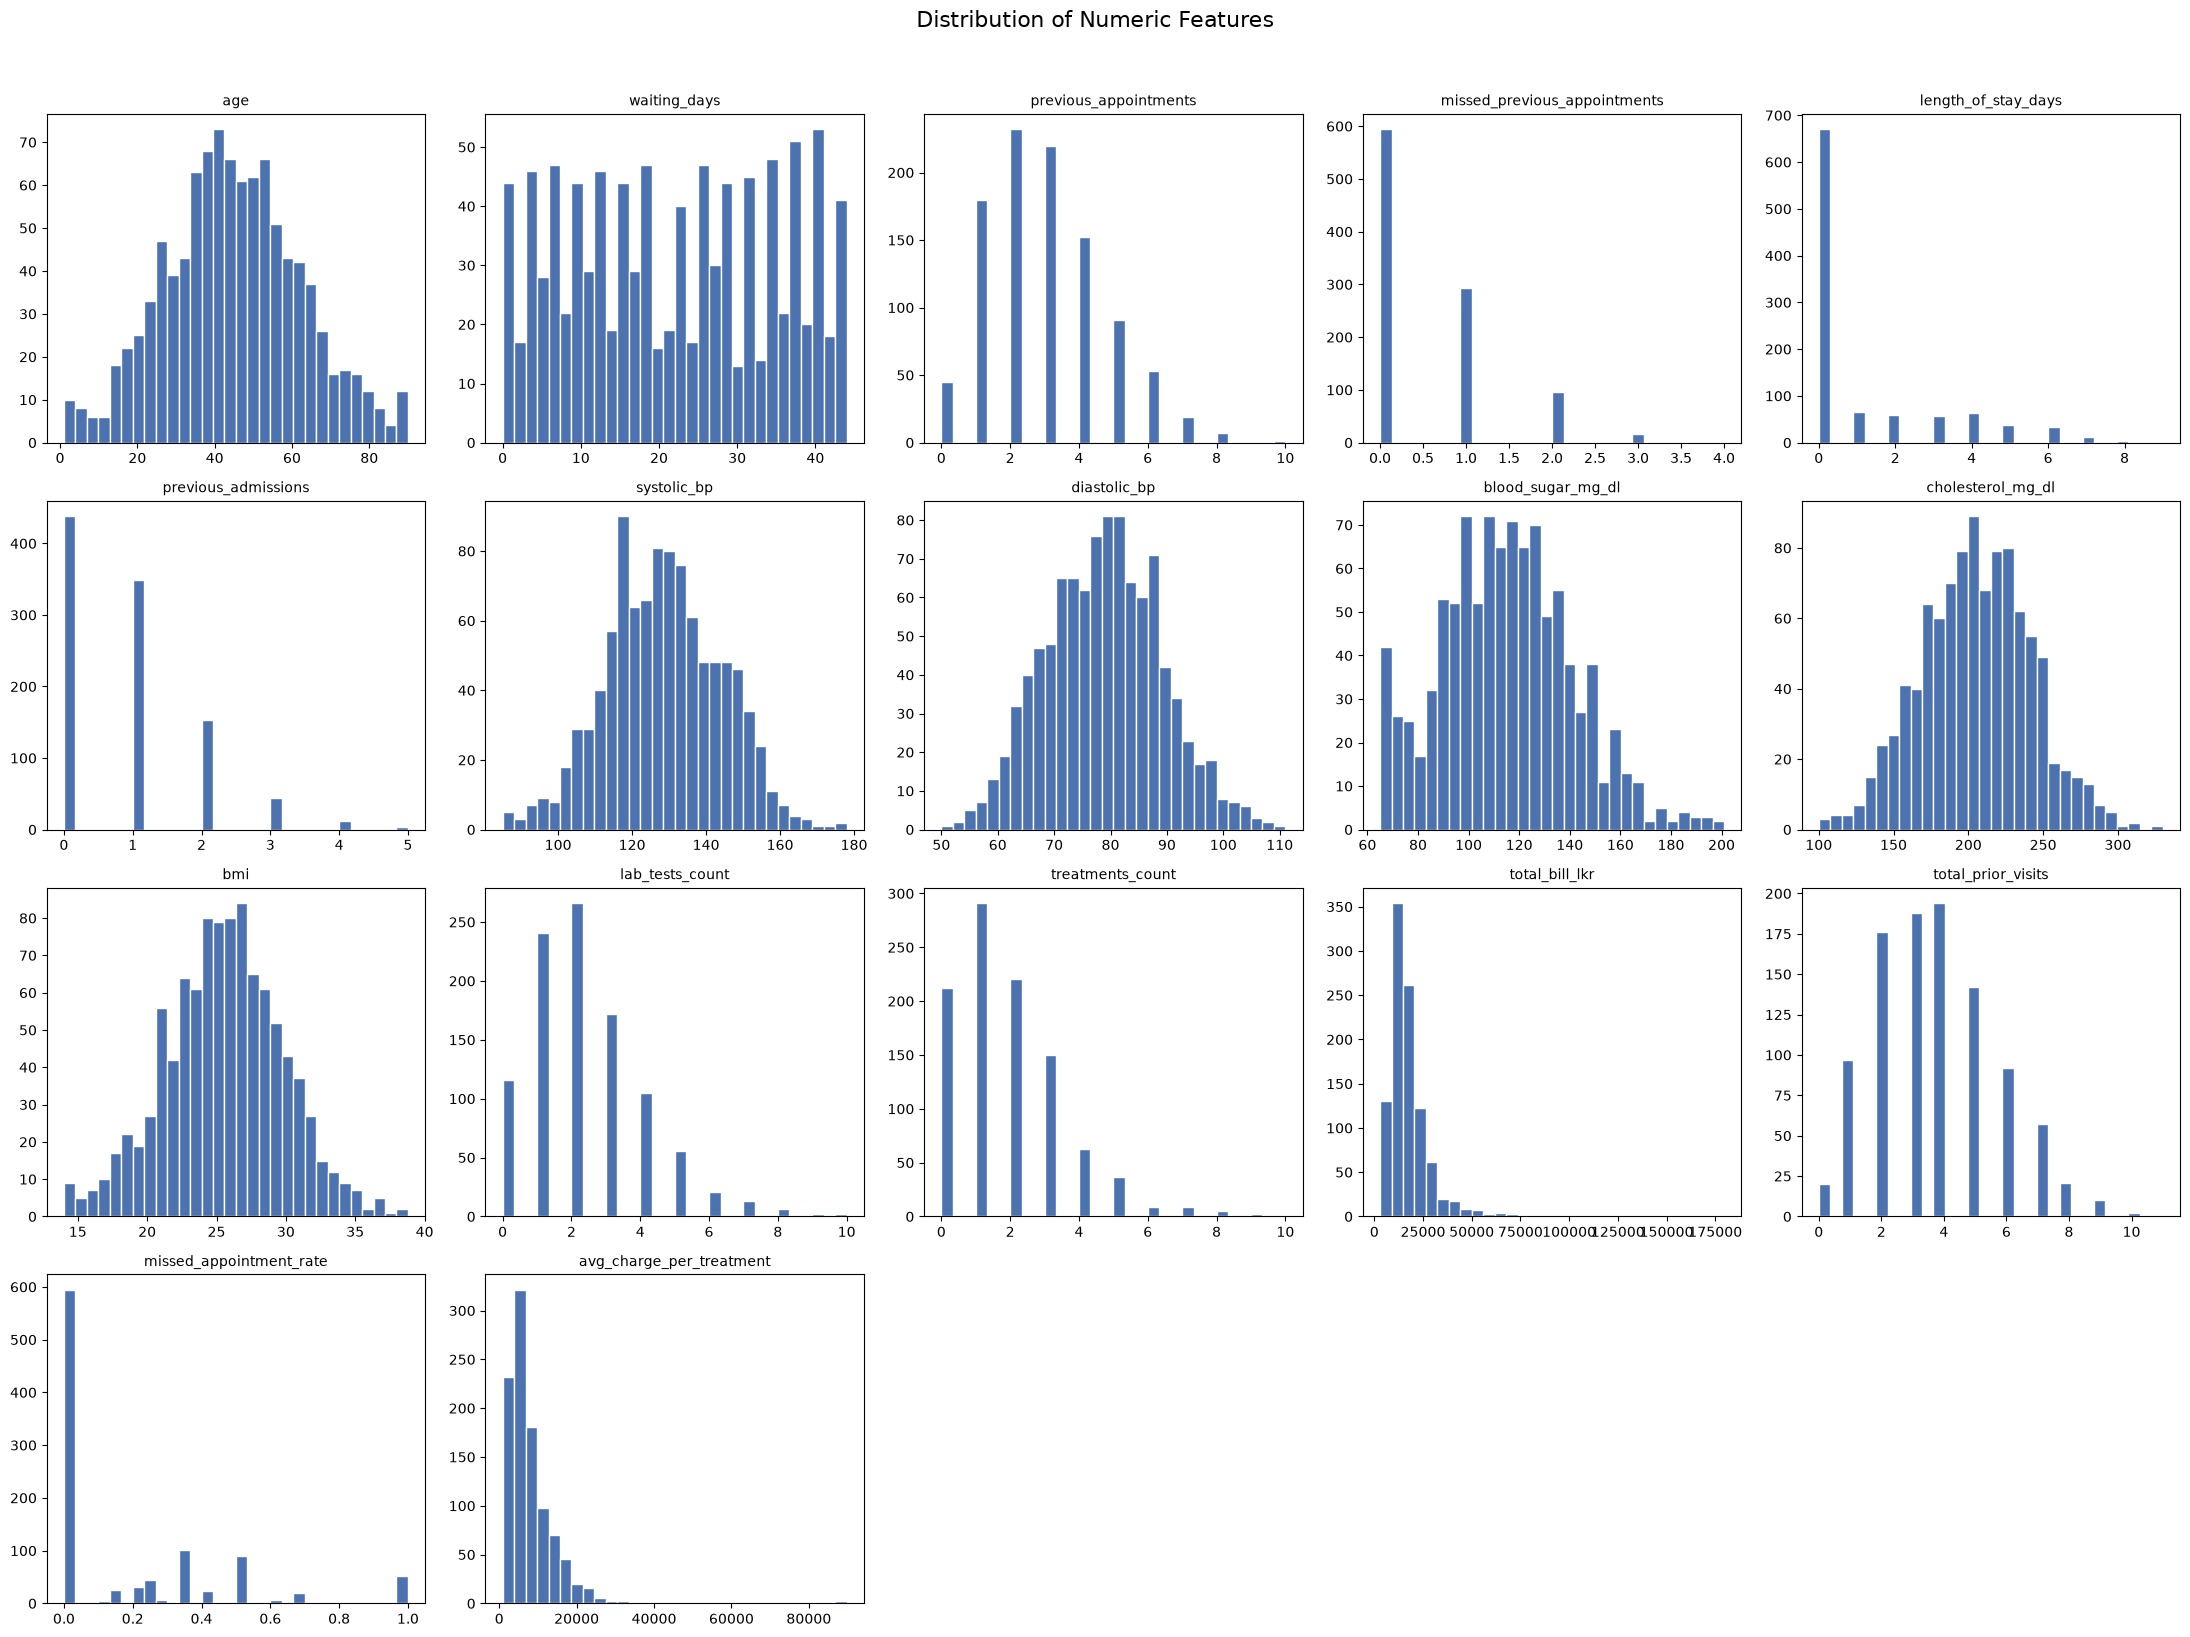

In [7]:
hist_cols = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments',
             'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
             'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count',
             'total_bill_lkr', 'total_prior_visits', 'missed_appointment_rate', 'avg_charge_per_treatment']

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    axes[i].hist(eda_df[col], bins=30, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(hist_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_histograms.png', dpi=110, bbox_inches='tight')
plt.show()

Most vitals like age, BP, cholesterol, BMI, blood sugar are roughly normal with low skew. Billing and utilisation features such as **"total_bill_lkr", "avg_charge_per_treatment", "length_of_stay_days", "previous_admissions"** are right-skewed. Most values are low, with a few high-cost or long-stay outliers. This supports using StandardScaler and flags these features as log-transform candidates.

In [8]:
skew_table = eda_df[hist_cols].skew().sort_values(ascending=False)
print('Skewness of numeric features (sorted):')
skew_table

Skewness of numeric features (sorted):


total_bill_lkr                  4.945223
avg_charge_per_treatment        4.728385
length_of_stay_days             1.634012
missed_appointment_rate         1.578146
missed_previous_appointments    1.277362
treatments_count                1.267012
previous_admissions             1.194906
lab_tests_count                 1.023404
previous_appointments           0.590053
total_prior_visits              0.447754
blood_sugar_mg_dl               0.282577
diastolic_bp                    0.092851
age                             0.076627
waiting_days                    0.029683
systolic_bp                     0.022541
cholesterol_mg_dl               0.011057
bmi                            -0.040517
dtype: float64

## 4.3. Boxplots - Numerical Features by Target Class

C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\1779085220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=eda_df, ax=axes[i], palette='Set2')
C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\1779085220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=eda_df, ax=axes[i], palette='Set2')
C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\1779085220.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=eda_df, ax=axes[i], palette='Set2')
C:\Users\kalua\AppData\Local\Temp\

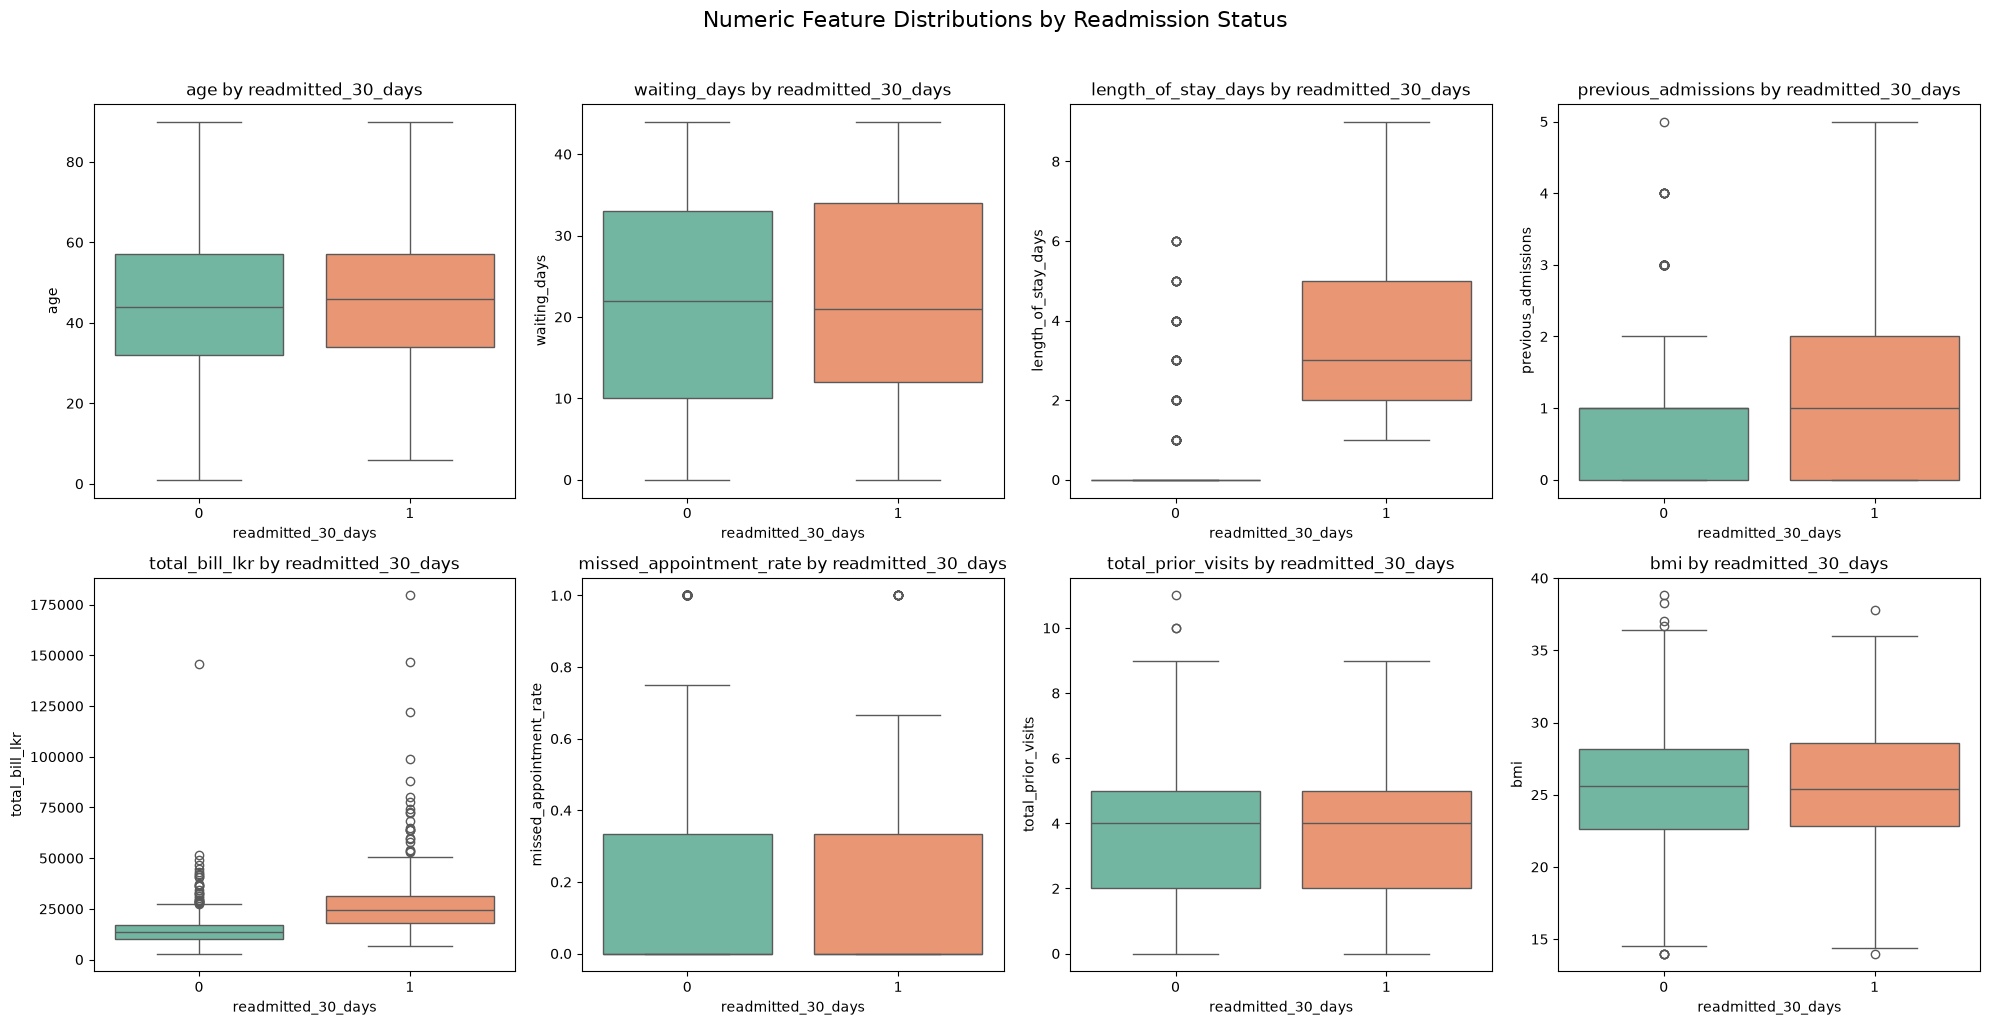

In [9]:
box_cols = ['age', 'waiting_days', 'length_of_stay_days', 'previous_admissions',
            'total_bill_lkr', 'missed_appointment_rate', 'total_prior_visits', 'bmi']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(x=target, y=col, data=eda_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by {target}')

plt.suptitle('Numeric Feature Distributions by Readmission Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_boxplots_by_target.png', dpi=110, bbox_inches='tight')
plt.show()

**"length_of_stay_days"** and **"total_bill_lkr"** show clear separation where readmitted patients have higher medians. **"previous_admissions"** is slightly higher too. Age, waiting days, BMI, and missed-appointment rate look nearly the same across both classes, so they're weak predictors alone.

## 4.4. Correlation Analysis

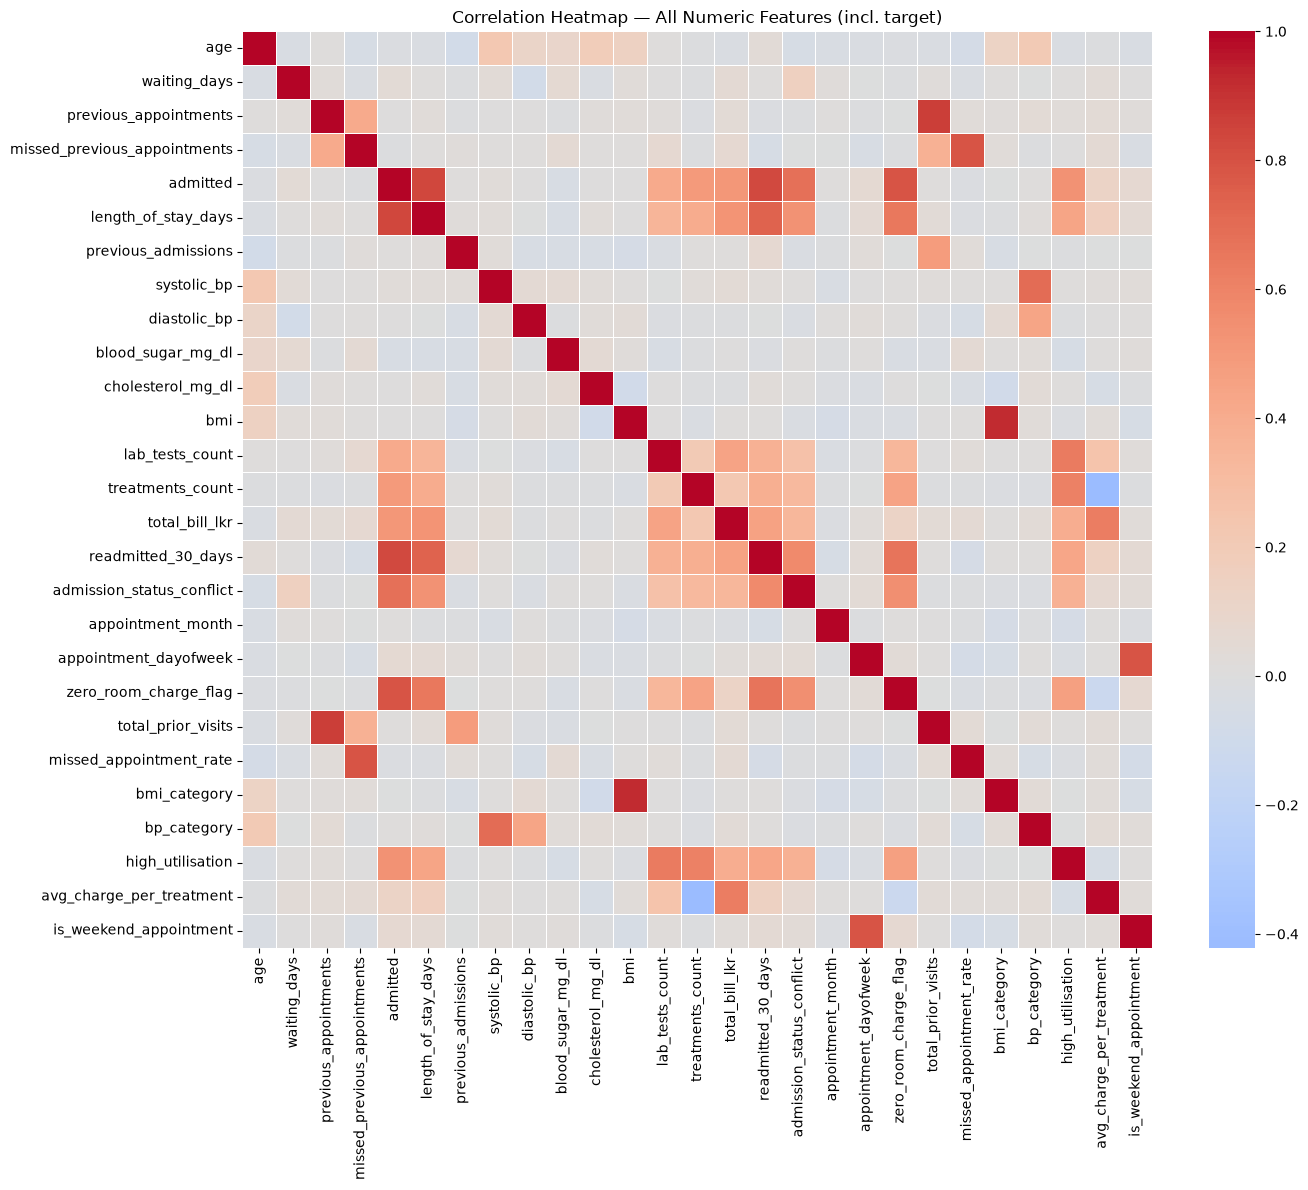

In [10]:
corr_full = eda_df[eda_numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_full, cmap='coolwarm', center=0, annot=False, linewidths=0.4)
plt.title('Correlation Heatmap — All Numeric Features (incl. target)')
plt.tight_layout()
plt.savefig('../outputs/eda_correlation_heatmap_full.png', dpi=110, bbox_inches='tight')
plt.show()

**"admitted, length_of_stay_days, zero_room_charge_flag,"** and **"admission_status_conflict"** have the strongest correlation with the target (0.57–0.83). Clinical vitals (age, BP, cholesterol, BMI) are near-zero correlated. So the model will rely mostly on admissionor utilisation features, not vitals.

In [11]:
target_corr = corr_full[target].drop(target).sort_values(key=abs, ascending=False)
print('Correlation of numeric features with the target (sorted by strength):')
target_corr

Correlation of numeric features with the target (sorted by strength):


admitted                        0.829240
length_of_stay_days             0.734844
zero_room_charge_flag           0.667900
admission_status_conflict       0.573090
total_bill_lkr                  0.453418
high_utilisation                0.438295
treatments_count                0.386763
lab_tests_count                 0.367357
avg_charge_per_treatment        0.150580
previous_admissions             0.064067
missed_appointment_rate        -0.059059
is_weekend_appointment          0.054463
missed_previous_appointments   -0.052363
appointment_month              -0.050978
appointment_dayofweek           0.038986
age                             0.034263
systolic_bp                     0.026746
cholesterol_mg_dl               0.026569
blood_sugar_mg_dl              -0.019859
previous_appointments          -0.018554
total_prior_visits              0.015488
waiting_days                    0.014947
bmi                             0.013295
bp_category                     0.012988
bmi_category    

## 4.5. Scatterplots - Feature Relationships

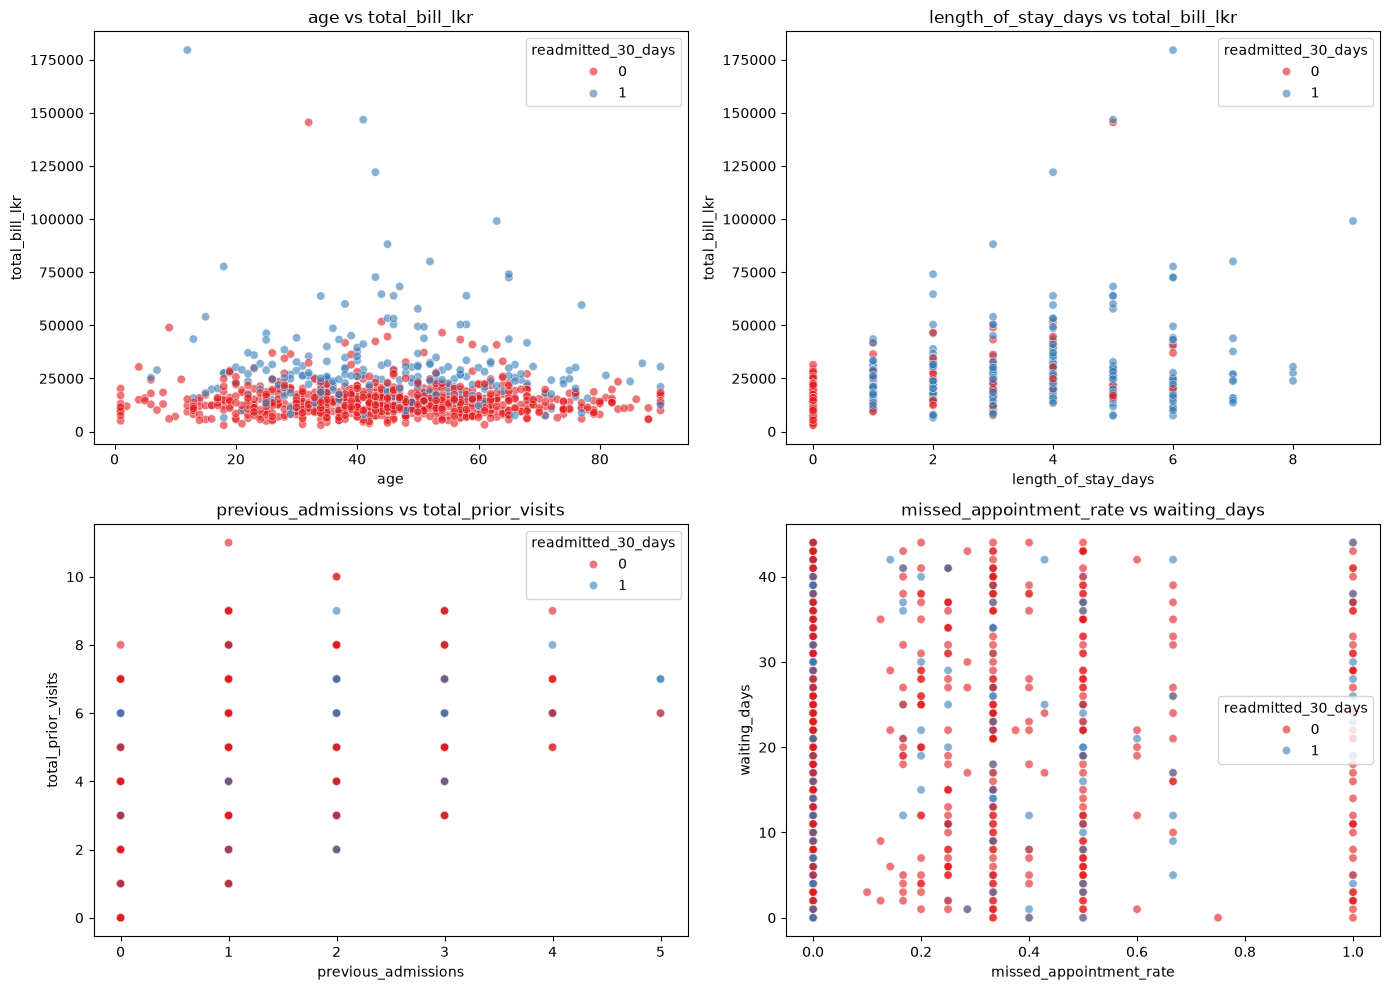

In [12]:
scatter_pairs = [
    ('age', 'total_bill_lkr'),
    ('length_of_stay_days', 'total_bill_lkr'),
    ('previous_admissions', 'total_prior_visits'),
    ('missed_appointment_rate', 'waiting_days'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(scatter_pairs):
    sns.scatterplot(x=x, y=y, hue=target, data=eda_df, alpha=0.6, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{x} vs {y}')

plt.tight_layout()
plt.savefig('../outputs/eda_scatterplots.png', dpi=110, bbox_inches='tight')
plt.show()

**"length_of_stay_days"** vs **"total_bill_lkr"** shows a clear positive trend, with readmitted patients clustering higher on both. **"age"** vs **"total_bill_lkr"** shows no age trend, but readmitted patients still bill higher on average. **"previous_admissions"** vs **"total_prior_visits"** and **"missed_appointment_rate"** vs **"waiting_days"** show no separation between classes.

## 4.6. Class Distribution Charts

C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\3409998334.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=eda_df, ax=axes[0], palette='Set2')
C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\3409998334.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=eda_df, order=order, ax=axes[i], palette='Set3')
C:\Users\kalua\AppData\Local\Temp\ipykernel_24036\3409998334.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=eda_df, order=order, ax=axes[i], palette='Set3')
C:\Users\kalua\AppData\Loca

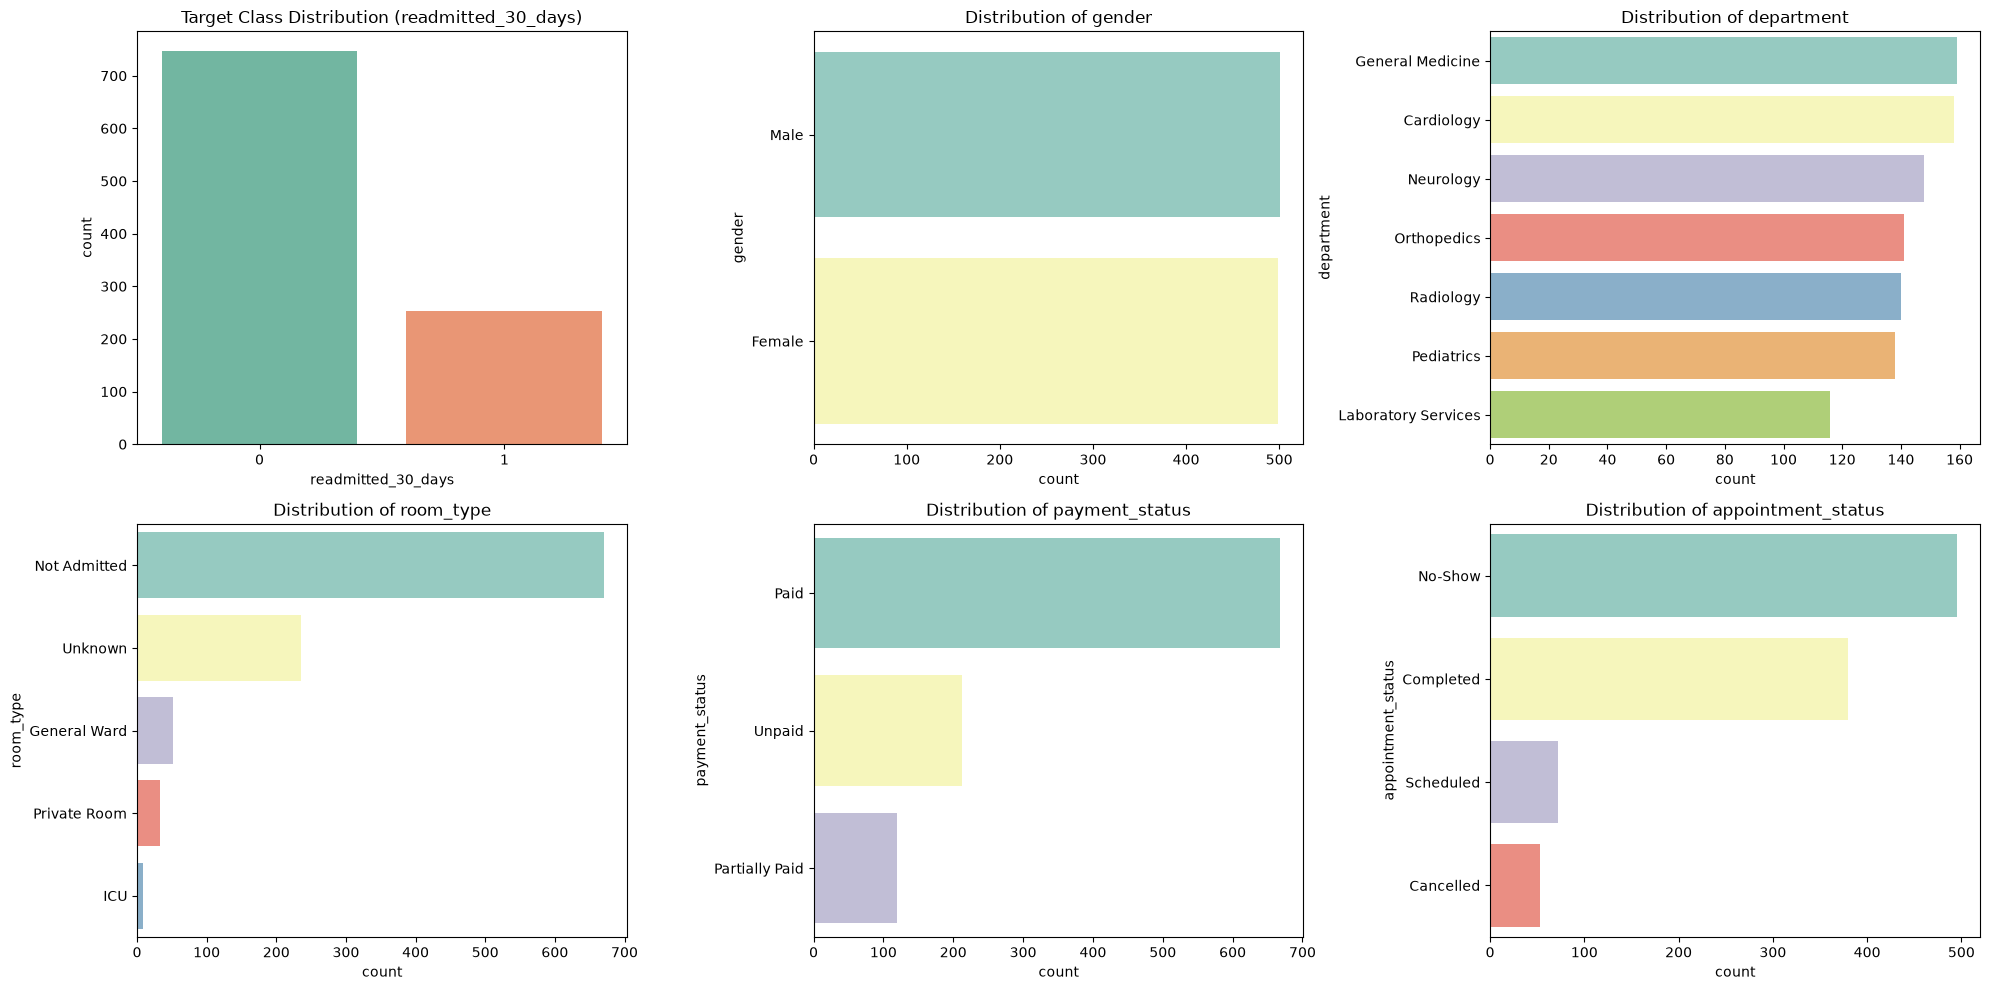

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

sns.countplot(x=target, data=eda_df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Distribution (readmitted_30_days)')

cat_plot_cols = ['gender', 'department', 'room_type', 'payment_status', 'appointment_status']
for i, col in enumerate(cat_plot_cols, start=1):
    order = eda_df[col].value_counts().index
    sns.countplot(y=col, data=eda_df, order=order, ax=axes[i], palette='Set3')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('../outputs/eda_class_distributions.png', dpi=110, bbox_inches='tight')
plt.show()

Target is imbalanced (~75% not readmitted, ~25% readmitted). Gender is approximately 50/50. Departments are fairly even. Room type is mostly "Not Admitted." Payment status is mostly "Paid." Appointment status is mostly "No-Show."

## 4.7. Pattern Discovery - Readmission Rate by Category

In [14]:
for col in ['department', 'room_type', 'payment_status', 'bmi_category', 'bp_category', 'gender']:
    rate = (eda_df.groupby(col)[target].mean() * 100).round(1).sort_values(ascending=False)
    print(f'\nReadmission rate (%) by {col}:')
    print(rate)


Readmission rate (%) by department:
department
Radiology              30.7
Pediatrics             28.3
Cardiology             26.6
Neurology              25.7
Orthopedics            24.8
Laboratory Services    23.3
General Medicine       18.2
Name: readmitted_30_days, dtype: float64

Readmission rate (%) by room_type:
room_type
Private Room    81.8
Unknown         77.5
General Ward    71.2
ICU             66.7
Not Admitted     0.0
Name: readmitted_30_days, dtype: float64

Readmission rate (%) by payment_status:
payment_status
Unpaid            27.4
Paid              24.9
Partially Paid    24.2
Name: readmitted_30_days, dtype: float64

Readmission rate (%) by bmi_category:
bmi_category
3    27.7
1    26.9
2    23.6
0    19.6
Name: readmitted_30_days, dtype: float64

Readmission rate (%) by bp_category:
bp_category
2    26.0
1    25.1
0    24.4
Name: readmitted_30_days, dtype: float64

Readmission rate (%) by gender:
gender
Female    27.1
Male      23.6
Name: readmitted_30_days, dtype: 

Radiology and Pediatrics have the highest department readmission rates. General Medicine is the lowest. Room type shows the biggest gap: admitted patients in Private/ICU/General Wards have 67-82% readmission vs a **flat 0%** for "Not Admitted" patients.

**Limitation — possible target-construction artefact:** a 0% rate with no exceptions across 670 "Not Admitted" records is a stronger and cleaner split than typical real-world clinical data would produce; some genuinely non-admitted patients would ordinarily still be readmitted. This suggests `readmitted_30_days` in this synthetic dataset may have been generated partly *from* `admitted` (and correlated fields like `room_type` / `length_of_stay_days`), rather than the correlation being purely a discovered clinical relationship. If so, model performance metrics in Task 05/06 are likely inflated relative to a real hospital deployment, and this should be stated explicitly as a limitation rather than only as a modelling insight (see Section [Limitations] of the report).

## 4.8. Summery of EDA Insigts

**EDA Summary — Task 04**

- **Target:** Imbalanced — aproximately 75% is not readmitted while 25% is readmitted.

- **Vitals** (age, BP, cholesterol, BMI, blood sugar): These have a near-normal distribution with low skew and a weak correlation with target.

- **Billing/utilisation features** (**"total_bill_lkr", "avg_charge_per_treatment", "length_of_stay_days"**)     right-skewed, few high-cost outliers.

- **Strongest predictors:** **"admitted", "length_of_stay_days", "zero_room_charge_flag", "admission_status_conflict"**.

- **Weak predictors:** age, waiting days, BMI, missed-appointment rate, previous admissions.

- **Boxplots:** readmitted patients have higher **"length_of_stay_days"** and **"total_bill_lkr"**.

- **Scatterplots:** positive trend between **length_of_stay_days"** and **"total_bill_lkr"**; no clear pattern for other pairs.

- **Categorical spread:** gender ~50/50, departments fairly even, room type mostly "Not Admitted," payment mostly "Paid," appointment status mostly "No-Show."

- **Readmission by category:** highest in Radiology/Pediatrics; room type shows biggest gap (67–82% for admitted vs a flat 0% for not-admitted); payment/BMI/BP/gender show little variation.

- **Limitation:** the flat 0% readmission rate for all non-admitted patients is unusually clean for real clinical data and suggests the synthetic target may be partly derived from `admitted`/`room_type`/`length_of_stay_days`, which would inflate downstream model performance and limit how far these results generalise beyond this dataset.

- **Key takeaway:** Admission-related features drive readmission risk far more than demographics or clinical vitals; class imbalance means accuracy alone won't be a reliable metric later.